In [1]:
import pandas as pd
import torch
from data_load import data_load, imshow
import matplotlib.pyplot as plt
import torchvision
import numpy as np
from train import training_loop
from inference import inference
from model import CNN
import pytorch_lightning as pl
import os



c:\Users\hozen\anaconda3\envs\chest_xray\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Seed set to 1



 Example Batch:


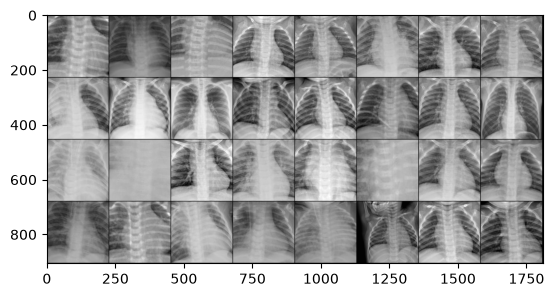

Label:
tensor([1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0,
        1, 1, 1, 1, 1, 0, 0, 0])

 Start Training:
Epoch 0  Average Training Loss:  0.6892, Average Validation Loss:  0.6633, Accuracy:  0.5833, Best Validation Loss:  0.6633
0.001
Epoch 1  Average Training Loss:  0.6549, Average Validation Loss:  0.6247, Accuracy:  0.7500, Best Validation Loss:  0.6247
0.001
Epoch 2  Average Training Loss:  0.6519, Average Validation Loss:  0.5865, Accuracy:  0.7500, Best Validation Loss:  0.5865
0.001
Epoch 3  Average Training Loss:  0.6016, Average Validation Loss:  0.5966, Accuracy:  0.7000, Best Validation Loss:  0.5865
0.001
Epoch 4  Average Training Loss:  0.5938, Average Validation Loss:  0.5806, Accuracy:  0.6833, Best Validation Loss:  0.5806
0.001
Epoch 5  Average Training Loss:  0.6038, Average Validation Loss:  0.5314, Accuracy:  0.7500, Best Validation Loss:  0.5314
0.001
Epoch 6  Average Training Loss:  0.5502, Average Validation Loss:  0.5484, Accurac

In [2]:
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
torch.use_deterministic_algorithms(True, warn_only=True)

SEED = 1
pl.seed_everything(SEED, workers=True)

train_loader, val_loader, test_loader = data_load()

print("\n Example Batch:")
x, y = next(iter(train_loader))
imshow(torchvision.utils.make_grid(x))
print("Label:")
print(y)


lr = 1e-3
num_epoch = 1000
patience= 50
#step_size = 20
factor = 0.5
print("\n Start Training:")
train_loss_list, val_loss_list, val_acc_list = training_loop(train_loader, val_loader, model = CNN(num_classes=2), lr = lr, num_epoch = num_epoch, patience= patience, factor=factor)

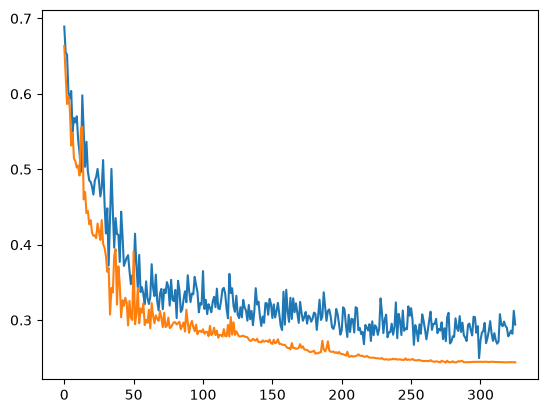

In [3]:
plt.plot(train_loss_list)
plt.plot(val_loss_list)
plt.show()

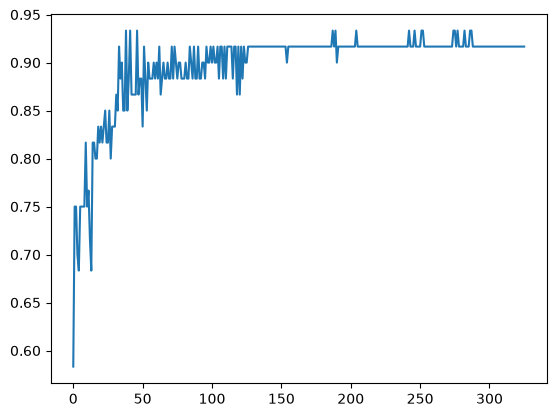

In [4]:
plt.plot(val_acc_list)
plt.show()

In [5]:
import numpy as np
min_loss = min(val_loss_list)
min_loss_idx = np.argmin(val_loss_list)
min_loss_acc = val_acc_list[min_loss_idx]

In [6]:
print(f"Model: mini_vgg_acc_{min_loss_acc*100:.2f}_loss_{min_loss:.4f}_lr_{lr}_epoches_{len(val_loss_list)-1}_patience_{patience}")
inference(f"../saved_models\mini_vgg_acc_{min_loss_acc*100:.2f}_loss_{min_loss:.4f}_lr_{lr}_epoches_{len(val_loss_list)-1}_patience_{patience}",test_loader)

Model: mini_vgg_acc_93.33_loss_0.2437_lr_0.001_epoches_325_patience_50
Test Accuracy:  0.81
